# RACE RC & Quiz Generation - Exploratory Data Analysis (EDA)
This notebook performs a comprehensive analysis of the RACE dataset to satisfy project rubric requirements.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ── DRIVE MOUNTING ───────────────────────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/race_rc_project/data/raw/train.csv'
LOCAL_PATH = '../data/raw/train.csv'

if os.path.exists('/content/sample_data'):
    from google.colab import drive
    drive.mount('/content/drive')
    train_path = DRIVE_PATH
else:
    train_path = LOCAL_PATH

df = pd.read_csv(train_path)
print("1. Data Overview")
print(df.head())
print("\nShape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Data Overview
   Unnamed: 0              id  \
0           0  middle7348.txt   
1           1  middle7348.txt   
2           2  middle4305.txt   
3           3  middle4305.txt   
4           4  middle4305.txt   

                                             article  \
0  In the summer between my first year and second...   
1  In the summer between my first year and second...   
2  A bumpkin   went to a big city for the first t...   
3  A bumpkin   went to a big city for the first t...   
4  A bumpkin   went to a big city for the first t...   

                                            question  \
0  Before the writer came to the high school summ...   
1  How many times did the writer invite the boy t...   
2                         The bumpkin thought   _  .   
3                 The room he saw was perhaps   _  .   
4  We can see that the bumpkin had no 

## 2. Missing Value Analysis

Missing Values per Column:
Unnamed: 0    0
id            0
article       0
question      0
A             4
B             0
C             1
D             9
answer        0
dtype: int64


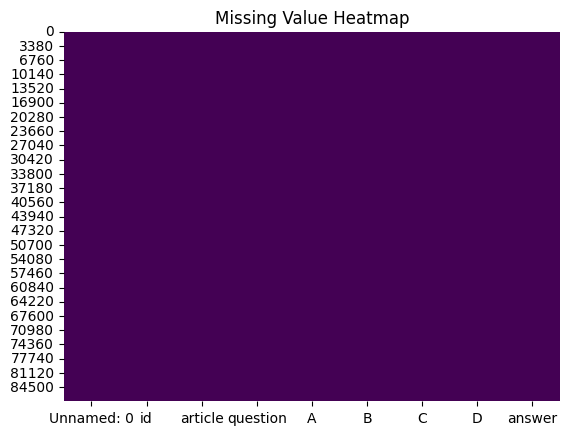

In [8]:
print("Missing Values per Column:")
print(df.isnull().sum())

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

## 3. Statistical Analysis

In [9]:
# Feature Engineering for Analysis
df['article_len'] = df['article'].apply(lambda x: len(str(x).split()))
df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))

print("Statistical Summary of Lengths:")
print(df[['article_len', 'question_len']].describe())

Statistical Summary of Lengths:
        article_len  question_len
count  87866.000000  87866.000000
mean     274.983702     10.008786
std       97.881345      3.382040
min        2.000000      1.000000
25%      217.000000      8.000000
50%      279.000000     10.000000
75%      326.000000     12.000000
max     1162.000000     63.000000


## 4. Outlier Detection

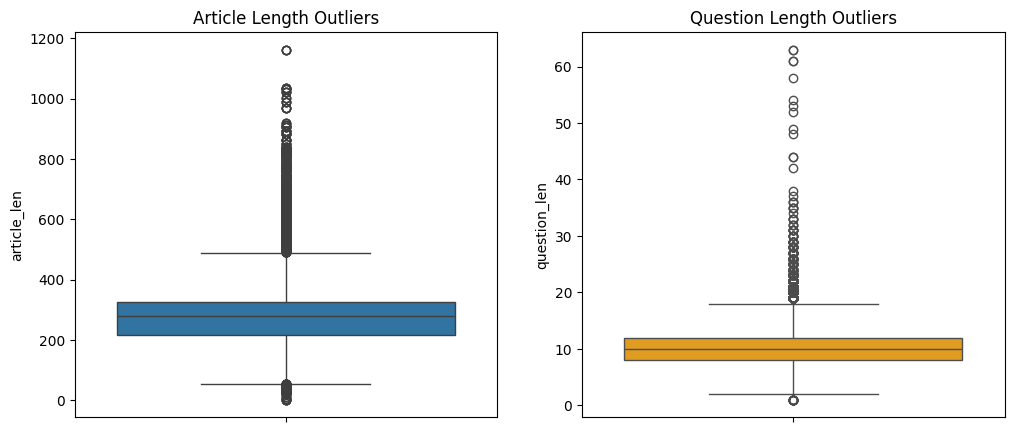

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['article_len'])
plt.title('Article Length Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['question_len'], color='orange')
plt.title('Question Length Outliers')
plt.show()

## 5. Data Distribution & Correlation Analysis

/tmp/ipykernel_10572/3696249251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='answer', data=df, palette='Set2')


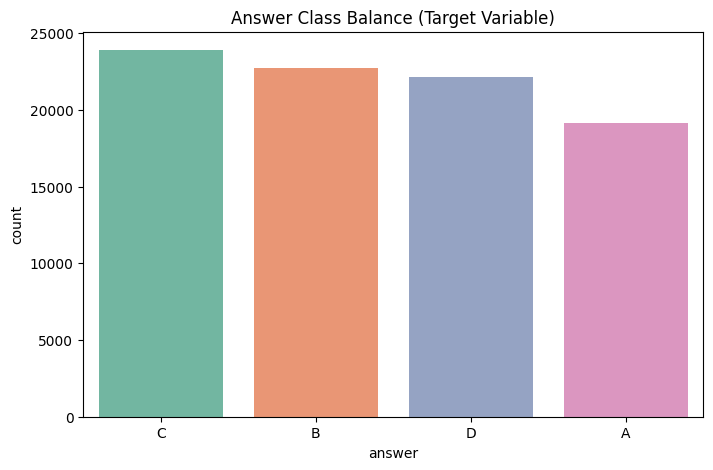

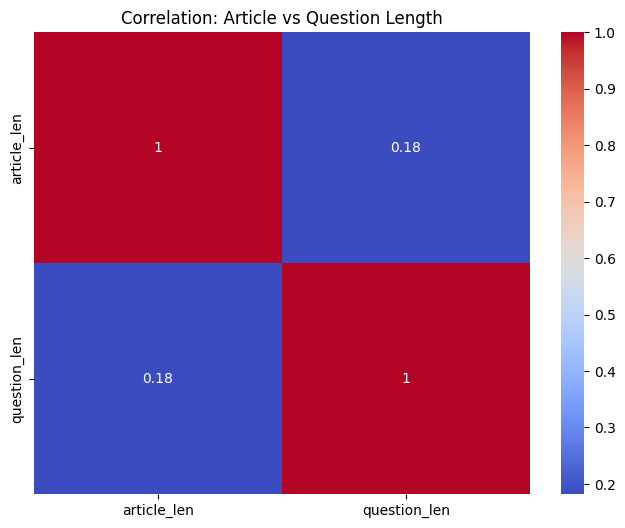

In [11]:
# Answer Distribution (Answer Balance)
plt.figure(figsize=(8, 5))
sns.countplot(x='answer', data=df, palette='Set2')
plt.title('Answer Class Balance (Target Variable)')
plt.show()

# Correlation Analysis
plt.figure(figsize=(8, 6))
sns.heatmap(df[['article_len', 'question_len']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation: Article vs Question Length')
plt.show()

## 6. Feature Relationships

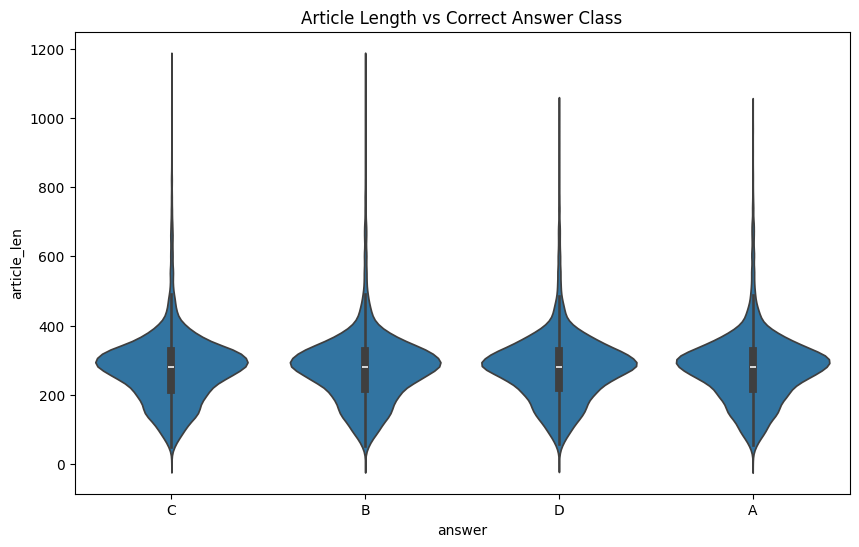

In [12]:
# Relationship between Answer and Article Length
plt.figure(figsize=(10, 6))
sns.violinplot(x='answer', y='article_len', data=df)
plt.title('Article Length vs Correct Answer Class')
plt.show()